In [ ]:
!pip install spacy


In [ ]:
!python -m spacy download fr_core_news_md


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 13.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Etape 1:Data Extraction with spacy**

In [ ]:
import requests
from bs4 import BeautifulSoup
import spacy
import pandas as pd

# Charger le modèle NLP français
nlp = spacy.load("fr_core_news_md")

# Liste enrichie de mots-clés pour animaux, symptômes, remèdes et traitements
animaux =[
    "chien", "chat", "chiens", "chats", "lapin", "lapins", "hamster", "hamsters", "cochon d'Inde", "cobaye", "cheval",
    "vache", "mouton", "porc", "poulet", "poule", "canard", "oiseau", "poisson", "iguane", "tortue", "rongeur", "rat",
    "souris", "serpent", "furet", "gerbille", "perruche", "ara", "calopsitte", "singe", "chien de berger", "bouledogue",
    "beagle", "dalmatien", "persan", "siamois", "maine coon", "bengal", "chinchilla", "dègue du chili", "hérisson",
    "phalanger volant", "paon", "carpe", "ver à soie", "dromadaire", "cochon", "chèvre", "âne", "lama", "alpaga"
]

# Symptômes
symptomes_clés =[
    "digestion", "inflammation", "peau", "parasite", "douleur", "stress", "toxine", "foie", "infection", "arthrose",
    "vomissement", "diarrhée", "fièvre", "perte de poids", "faiblesse", "maux de tête", "toux", "conjonctivite", "pâleur",
    "fatigue", "démangeaison", "irritation", "gros ventre", "inappétence", "cicatrices", "vomissements", "essoufflement",
    "grosseur", "problèmes digestifs", "absentéisme alimentaire", "tremblements", "léthargie", "respiration anormale",
    "changement d'appétit", "soif excessive", "urines fréquentes", "gonflement des gencives", "difficultés à uriner",
    "éternuements", "éruptions cutanées", "hypertension", "nervosité", "dépression", "mauvaise haleine", "allergies",
    "plaies", "entorses", "infections urinaires", "problèmes de vessie", "troubles digestifs", "anxiété", "arthrite",
    "problèmes de peau", "pelage terne", "problèmes respiratoires", "problèmes oculaires", "problèmes dentaires",
    "problèmes auditifs", "problèmes de comportement", "problèmes de mobilité", "problèmes de reproduction",
    "problèmes de croissance", "problèmes de poids", "problèmes de sommeil", "problèmes de vision"
]
# Traitements (inchangés)
traitements_clés = [
    "mélanger", "vaporiser", "administrer", "donner", "ajouter", "application",
    "comprimé", "infusion", "huile", "poudre", "gemmothérapie", "hydrolats",
    "élixirs floraux", "extraits phytostandardisés", "homéopathie", "argile verte",
    "huiles essentielles", "décoction"
]
# Remèdes
remedes_clés = [
    "curcuma", "spiruline", "nigelle", "chardon", "aloé", "ail", "neem", "pastèque", "olivier", "cenelle",
    "champignon", "gingembre", "camomille", "lavande", "romarin", "eucalyptus", "miel", "thym", "cannelle", "menthe",
    "argile", "basilic", "propolis", "levure de bière", "huile de pépin de melon", "avoine colloïdale", "huile de coco",
    "argent colloïdal"
]

# URLs à scraper
urls = [
    "https://www.fao.org/4/t0690f/t0690f0b.htm#TopOfPage",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/la-graine-de-nigelle-la-graine-benie-habat-al-barakah/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/petit-guide-de-la-spiruline-pour-chiens-et-chats/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/le-chardon-marie-une-pas-si-mauvaise-herbe/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/triptyque-de-plantes-pour-proteger-vos-animaux-de-compagnie-des-tiques-des-puces-et-des-moustiques/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/la-pasteque-une-excellente-addition-a-l-alimentation-de-votre-chien/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/le-feuilles-d-olivier-un-must-dans-la-boite-a-pharmacie-de-snoopy/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/les-cenelles-un-excellent-tonique-cardiaque/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/le-curcuma-pour-chiens-et-chats/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/l-ail-ses-nombreux-bienfaits-et-ses-precautions-d-usage/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/les-tops-champignons-comestibles-et-medicinaux/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/le-neem-margousier-le-remede-ayurvedique-tout-usage/",
    "https://www.vismedicatrixnaturae.fr/remedes-recettes/les-plantes-medicinales/l-aloe-vera-et-ses-bienfaits-pour-vos-animaux-de-compagnie/",
    "https://www.aroma-zone.com/page/huiles-essentielles-chien",
    "https://www.aroma-zone.com/page/huiles-essentielles-chat",
    "https://www.terrevivante.org/contenu/comment-soigner-chat-chien-naturellement/",
    "https://happydogdayspa.ch/articles-du-blog/5-remedes-naturels-pour-vos-animaux/",
    "https://www.lekaba.fr/article/quelles-methodes-naturelles-pour-prendre-soin-de-ses-animaux",
    "https://www.remedes-animaux.org/"
]

# Fonction pour vérifier si une phrase contient un mot-clé
def contient_mot(texte, mots_cles):
    return [mot for mot in mots_cles if mot in texte]

# Extraction avancée par phrase
def extraire_infos_avancees(texte):
    results = []

    # Exclure "animaux" et "animal" pour éviter des résultats trop génériques
    animaux_detectés = [mot for mot in contient_mot(texte, animaux) if mot not in ["animaux", "animal"]]

    # Si aucun animal spécifique n'est trouvé, on peut donner "Non précisé"
    if not animaux_detectés:
        animaux_detectés = ['Non précisé']

    remedes_detectés = contient_mot(texte, remedes_clés)
    symptomes_detectés = contient_mot(texte, symptomes_clés)
    traitements_detectés = contient_mot(texte, traitements_clés)

    for animal in animaux_detectés:
        for remede in remedes_detectés:
            if symptomes_detectés or traitements_detectés:
                for symptome in symptomes_detectés or ['']:
                    for traitement in traitements_detectés or ['']:
                        results.append({
                            'animal': animal.capitalize(),
                            'symptome': symptome,
                            'traitement': traitement,
                            'remede': remede.capitalize(),
                            'phrase': texte
                        })
            else:
                results.append({
                    'animal': animal.capitalize(),
                    'symptome': '',
                    'traitement': '',
                    'remede': remede.capitalize(),
                    'phrase': texte
                })
    return results

# Scraping + NLP
data = []

for url in urls:
    try:
        page = requests.get(url, timeout=10)
        soup = BeautifulSoup(page.content, 'html.parser')
        text = soup.get_text(separator=' ', strip=True)
        doc = nlp(text.lower())

        for sent in doc.sents:
            lignes = extraire_infos_avancees(sent.text)
            for ligne in lignes:
                ligne['source'] = url
                data.append(ligne)
    except Exception as e:
        print(f"Erreur avec {url}: {e}")

# Convertir en DataFrame
df = pd.DataFrame(data)

# Affichage du DataFrame
df.head()


,animal,symptome,traitement,remede,phrase,source
0,Non précisé,diarrhée,,Ail,"chez les volailles adultes, cette maladie prov...",https://www.fao.org/4/t0690f/t0690f0b.htm#TopO...
1,Non précisé,,,Ail,les animaux de taille plus grande ont besoin d...,https://www.fao.org/4/t0690f/t0690f0b.htm#TopO...
2,Non précisé,,,Ail,l'étouffement (nourriture bloquée dans l'œsoph...,https://www.fao.org/4/t0690f/t0690f0b.htm#TopO...
3,Non précisé,,,Ail,on la remarque aisément en observant les mouve...,https://www.fao.org/4/t0690f/t0690f0b.htm#TopO...
4,Non précisé,,,Ail,vous aurez besoin de l'aide du vétérinaire qua...,https://www.fao.org/4/t0690f/t0690f0b.htm#TopO...


**Etape 2:Data preparation**

In [ ]:
print(df.count())

animal        3616
symptome      3616
traitement    3616
remede        3616
phrase        3616
source        3616
dtype: int64


In [ ]:
print(df.nunique())


animal         16
symptome       25
traitement     16
remede         27
phrase        487
source         19
dtype: int64


In [ ]:
print(df['animal'].value_counts())


animal
Chien          640
Chiens         584
Chat           582
Chats          562
Ara            557
Non précisé    423
Rat            160
Furet           97
Porc             3
Oiseau           2
Cheval           1
Dalmatien        1
Mouton           1
Vache            1
Rongeur          1
Poisson          1
Name: count, dtype: int64


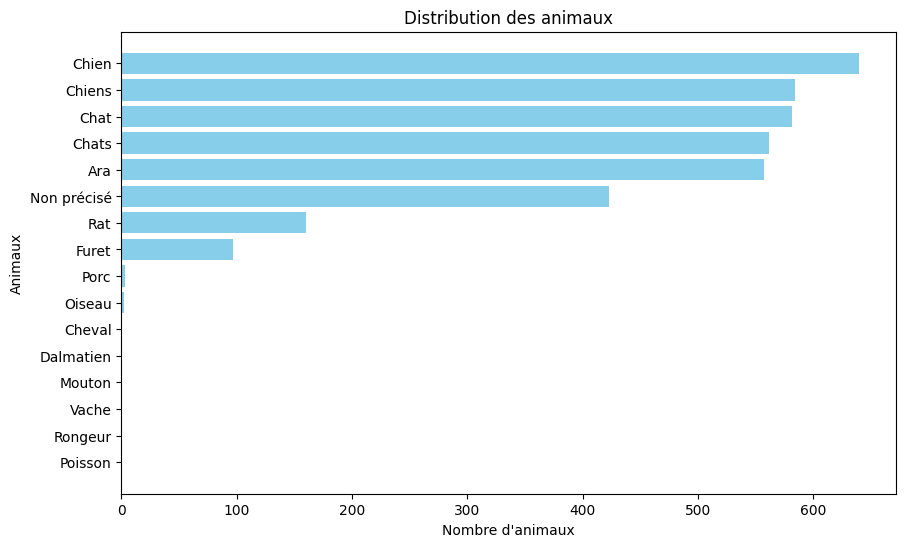

In [ ]:
import matplotlib.pyplot as plt

# Comptage des occurrences par animal
animal_counts = df['animal'].value_counts()

# Créer un graphique à barres horizontales
plt.figure(figsize=(10, 6))  # Définir la taille de la figure
plt.barh(animal_counts.index, animal_counts.values, color='skyblue')  # Graphique à barres horizontales
plt.xlabel('Nombre d\'animaux')  # Label de l'axe des x
plt.ylabel('Animaux')  # Label de l'axe des y
plt.title('Distribution des animaux')  # Titre du graphique
plt.gca().invert_yaxis()  # Inverser l'axe y pour que le plus grand nombre soit en haut
plt.show()


In [ ]:
print(df['symptome'].value_counts())
print(df['remede'].value_counts())


symptome
digestion               1084
stress                  1082
arthrose                 678
                         619
peau                      43
infection                 29
foie                      20
diarrhée                   9
inflammation               8
parasite                   7
démangeaison               5
infections urinaires       5
plaies                     4
troubles digestifs         4
toxine                     3
allergies                  3
douleur                    3
problèmes digestifs        2
irritation                 2
cicatrices                 1
toux                       1
hypertension               1
fatigue                    1
mauvaise haleine           1
anxiété                    1
Name: count, dtype: int64
remede
Ail                        437
Curcuma                    358
Propolis                   349
Menthe                     339
Neem                       323
Spiruline                  298
Nigelle                    293
Champignon      

In [ ]:
# Compter les valeurs nulles (NaN) dans chaque colonne du DataFrame
nombre_nulls_par_colonne = df.isnull().sum()

# Afficher le nombre de valeurs nulles pour chaque colonne
print(nombre_nulls_par_colonne)


animal        0
symptome      0
traitement    0
remede        0
phrase        0
source        0
dtype: int64


In [ ]:
# Supprimer la colonne 'source' du DataFrame
df = df.drop(columns=['source'])
df = df.drop(columns=['traitement'])

# Vérifier si la colonne 'source' a bien été supprimée
print(df.head())


        animal  symptome remede  \
0  Non précisé  diarrhée    Ail   
1  Non précisé              Ail   
2  Non précisé              Ail   
3  Non précisé              Ail   
4  Non précisé              Ail   

                                              phrase  
0  chez les volailles adultes, cette maladie prov...  
1  les animaux de taille plus grande ont besoin d...  
2  l'étouffement (nourriture bloquée dans l'œsoph...  
3  on la remarque aisément en observant les mouve...  
4  vous aurez besoin de l'aide du vétérinaire qua...  


In [ ]:
df.head()

,animal,symptome,remede,phrase
0,Non précisé,diarrhée,Ail,"chez les volailles adultes, cette maladie prov..."
1,Non précisé,,Ail,les animaux de taille plus grande ont besoin d...
2,Non précisé,,Ail,l'étouffement (nourriture bloquée dans l'œsoph...
3,Non précisé,,Ail,on la remarque aisément en observant les mouve...
4,Non précisé,,Ail,vous aurez besoin de l'aide du vétérinaire qua...


In [ ]:
# Compter les valeurs vides dans la colonne 'symptome' (y compris les chaînes vides)
empty_symptomes_count = df['symptome'].eq('').sum()

# Afficher le nombre de valeurs vides
print(f"Nombre de valeurs vides dans 'symptome' : {empty_symptomes_count}")


Nombre de valeurs vides dans 'symptome' : 619


In [ ]:
# Supprimer les lignes où la colonne 'animal' est égale à 'Non précisé'
df = df[df['animal'] != 'Non précisé']

# Afficher les premières lignes du DataFrame après suppression
print(df.head())


    animal   symptome     remede  \
9   Cheval                   Ail   
10     Ara               Nigelle   
11   Chien  digestion    Curcuma   
12   Chien     stress    Curcuma   
13   Chien  digestion  Spiruline   

                                               phrase  
9   donnez 10 g à un animal de petite taille et 20...  
10  la graine de nigelle, la graine benie « habat ...  
11  les consequences insoupconnees d’une mauvaise ...  
12  les consequences insoupconnees d’une mauvaise ...  
13  les consequences insoupconnees d’une mauvaise ...  


In [ ]:
print(df.count())


animal      3193
symptome    3193
remede      3193
phrase      3193
dtype: int64


In [ ]:
# Compter les valeurs vides dans la colonne 'symptome' (y compris les chaînes vides)
empty_symptomes_count = df['symptome'].eq('').sum()

# Afficher le nombre de valeurs vides
print(f"Nombre de valeurs vides dans 'symptome' : {empty_symptomes_count}")


Nombre de valeurs vides dans 'symptome' : 270


In [ ]:
import numpy as np

# Transformer les chaînes vides en NaN
df['symptome'].replace('', np.nan, inplace=True)

# Afficher les premières lignes du DataFrame après remplacement
print(df.head())


    animal   symptome     remede  \
9   Cheval        NaN        Ail   
10     Ara        NaN    Nigelle   
11   Chien  digestion    Curcuma   
12   Chien     stress    Curcuma   
13   Chien  digestion  Spiruline   

                                               phrase  
9   donnez 10 g à un animal de petite taille et 20...  
10  la graine de nigelle, la graine benie « habat ...  
11  les consequences insoupconnees d’une mauvaise ...  
12  les consequences insoupconnees d’une mauvaise ...  
13  les consequences insoupconnees d’une mauvaise ...  


<ipython-input-17-dc2a28fc664d>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['symptome'].replace('', np.nan, inplace=True)


In [ ]:
# Utiliser ffill pour remplir les valeurs manquantes (propagation des valeurs précédentes)
df['symptome'].ffill(inplace=True)

# Vérifier les résultats
print(df['symptome'].head())


9           NaN
10          NaN
11    digestion
12       stress
13    digestion
Name: symptome, dtype: object


<ipython-input-18-9bda045272a8>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['symptome'].ffill(inplace=True)


In [ ]:
# Remplacer les chaînes vides par "Non spécifié"
df['symptome'].replace( np.nan, 'Non spécifié', inplace=True)

# Vérifier les résultats
print(df['symptome'].head())


9     Non spécifié
10    Non spécifié
11       digestion
12          stress
13       digestion
Name: symptome, dtype: object


In [ ]:
df.head()

,animal,symptome,remede,phrase
9,Cheval,Non spécifié,Ail,donnez 10 g à un animal de petite taille et 20...
10,Ara,Non spécifié,Nigelle,"la graine de nigelle, la graine benie « habat ..."
11,Chien,digestion,Curcuma,les consequences insoupconnees d’une mauvaise ...
12,Chien,stress,Curcuma,les consequences insoupconnees d’une mauvaise ...
13,Chien,digestion,Spiruline,les consequences insoupconnees d’une mauvaise ...


In [ ]:
df.count()

,0
animal,3193
symptome,3193
remede,3193
phrase,3193


In [ ]:
print(df['animal'].value_counts())

animal
Chien        640
Chiens       584
Chat         582
Chats        562
Ara          557
Rat          160
Furet         97
Porc           3
Oiseau         2
Cheval         1
Dalmatien      1
Mouton         1
Vache          1
Rongeur        1
Poisson        1
Name: count, dtype: int64


In [ ]:
# Nettoyage : Conversion en minuscules, suppression des espaces, etc.
df['animal'] = df['animal'].str.lower().str.strip()
df['symptome'] = df['symptome'].str.lower().str.strip()
df['remede'] = df['remede'].str.lower().str.strip()
df['phrase'] = df['phrase'].str.lower().str.strip()

In [ ]:
# Exporter le DataFrame en un fichier CSV
df.to_csv('DataExtaction.csv', index=False)
